In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "co_bsm").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm

from co_bsm.black_scholes import BSMParams, bsm_call, bsm_put
from co_bsm.chooser import ChooserParams, chooser_price, chooser_price_rubinstein

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "PingFang SC",
                                   "Noto Sans CJK SC", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.float_format", "{:.4f}".format)

PAPER = dict(S=156.7, K=150.0, r=0.0015, sigma=0.282, q=0.0233, T1=0.5, T2=1.0)
VANILLA = dict(S=PAPER["S"], K=PAPER["K"], r=PAPER["r"], T=PAPER["T2"],
               sigma=PAPER["sigma"], q=PAPER["q"])

In [2]:
# CRR (1979) Table 2 中 n为无穷的一列：S = 40，年利率 5%（连续复利 ln 1.05），到期 1/4/7 个月
crr = {
    0.2: {35: (5.15, 5.76, 6.40), 40: (1.00, 2.17, 3.00), 45: (0.02, 0.51, 1.10)},
    0.3: {35: (5.22, 6.25, 7.17), 40: (1.46, 3.07, 4.19), 45: (0.16, 1.25, 2.24)},
    0.4: {35: (5.39, 6.89, 8.09), 40: (1.92, 3.98, 5.37), 45: (0.42, 2.10, 3.43)},
}

rows = []
for sigma, by_k in crr.items():
    for K, ref in by_k.items():
        for months, v_ref in zip((1, 4, 7), ref):
            v = bsm_call(BSMParams(S=40.0, K=K, r=np.log(1.05), T=months / 12, sigma=sigma))
            rows.append((sigma, K, months, v_ref, v))

crr_df = pd.DataFrame(rows, columns=["sigma", "K", "月数", "CRR", "本实现"])
crr_df["差"] = crr_df["本实现"] - crr_df["CRR"]
print(f"共 {len(crr_df)} 个价格，最大绝对差 {crr_df['差'].abs().max():.4f}（CRR 保留两位小数）")
crr_df.pivot_table(index=["sigma", "K"], columns="月数", values="本实现")

共 27 个价格，最大绝对差 0.0050（CRR 保留两位小数）


月数             1      4      7
sigma  K                      
0.2000 35 5.1482 5.7606 6.3991
       40 1.0028 2.1675 3.0037
       45 0.0225 0.5064 1.1029
0.3000 35 5.2191 6.2513 7.1711
       40 1.4614 3.0729 4.1860
       45 0.1622 1.2549 2.2352
0.4000 35 5.3878 6.8944 8.0950
       40 1.9202 3.9791 5.3699
       45 0.4188 2.1028 3.4283

In [3]:
# 随机参数下检验平价关系和股息处理
rng = np.random.default_rng(0)
n = 100_000
S = rng.uniform(20, 300, n)
K = rng.uniform(20, 300, n)
r = rng.uniform(-0.01, 0.10, n)
T = rng.uniform(0.01, 3.0, n)
sig = rng.uniform(0.05, 1.0, n)
q = rng.uniform(0.0, 0.08, n)

c = bsm_call(BSMParams(S, K, r, T, sig, q))
p = bsm_put(BSMParams(S, K, r, T, sig, q))
c0 = bsm_call(BSMParams(S * np.exp(-q * T), K, r, T, sig, 0.0))

checks = pd.Series({
    "平价关系 |C - P - (Se^{-qT} - Ke^{-rT})|": np.abs(c - p - (S * np.exp(-q * T) - K * np.exp(-r * T))).max(),
    "股息等价 |C(S, q) - C(Se^{-qT}, 0)|": np.abs(c - c0).max(),
    "下界 C ≥ max(Se^{-qT} - Ke^{-rT}, 0) 违反次数": np.sum(c < np.maximum(S * np.exp(-q * T) - K * np.exp(-r * T), 0) - 1e-9),
    "上界 C ≤ Se^{-qT} 违反次数": np.sum(c > S * np.exp(-q * T) + 1e-9),
}, name=f"{n:,} 组随机参数")
checks

平价关系 |C - P - (Se^{-qT} - Ke^{-rT})|      0.0000
股息等价 |C(S, q) - C(Se^{-qT}, 0)|           0.0000
下界 C ≥ max(Se^{-qT} - Ke^{-rT}, 0) 违反次数   0.0000
上界 C ≤ Se^{-qT} 违反次数                      0.0000
Name: 100,000 组随机参数, dtype: float64

In [4]:
# Table 2 参数下，公式价格与风险中性密度直接积分的对比
s0, k, rr, T2, sg, qq = VANILLA["S"], VANILLA["K"], VANILLA["r"], VANILLA["T"], VANILLA["sigma"], VANILLA["q"]
ST = lambda z: s0 * np.exp((rr - qq - 0.5 * sg**2) * T2 + sg * np.sqrt(T2) * z)
z_k = (np.log(k / s0) - (rr - qq - 0.5 * sg**2) * T2) / (sg * np.sqrt(T2))

call_int = np.exp(-rr * T2) * quad(lambda z: (ST(z) - k) * norm.pdf(z), z_k, 12, epsabs=1e-12)[0]
put_int = np.exp(-rr * T2) * quad(lambda z: (k - ST(z)) * norm.pdf(z), -12, z_k, epsabs=1e-12)[0]

pd.DataFrame({
    "公式": [bsm_call(BSMParams(**VANILLA)), bsm_put(BSMParams(**VANILLA))],
    "数值积分": [call_int, put_int],
}, index=["Call", "Put"]).assign(差=lambda d: d["公式"] - d["数值积分"])

,公式,数值积分,差
Call,18.6890,18.6890,0.0000
Put,15.3731,15.3731,-0.0000


In [5]:
# chooser 的几项一致性检验
tau = PAPER["T2"] - PAPER["T1"]
K_prime = PAPER["K"] * np.exp(-(PAPER["r"] - PAPER["q"]) * tau)
call_T2 = bsm_call(BSMParams(**VANILLA))
put_T2 = bsm_put(BSMParams(**VANILLA))
v = chooser_price(ChooserParams(**PAPER))

leg = dict(S=PAPER["S"], K=K_prime, r=PAPER["r"], T=PAPER["T1"], sigma=PAPER["sigma"], q=PAPER["q"])
v_sym = put_T2 + np.exp(-PAPER["q"] * tau) * bsm_call(BSMParams(**leg))

t1 = np.linspace(0.01, 1.0, 200)
curve = chooser_price(ChooserParams(**{**PAPER, "T1": t1}))

pd.DataFrame({
    "结果": [
        abs(v - chooser_price_rubinstein(ChooserParams(**PAPER))),
        abs(v - v_sym),
        abs(chooser_price(ChooserParams(**{**PAPER, "T1": 1.0})) - (call_T2 + put_T2)),
        abs(chooser_price(ChooserParams(**{**PAPER, "T1": 1e-8})) - max(call_T2, put_T2)),
        bool(np.all(np.diff(curve) > 0)),
        bool(np.all((curve >= max(call_T2, put_T2)) & (curve <= call_T2 + put_T2))),
    ]},
    index=[
        "分解形式与 Rubinstein 闭式解之差",
        "两种分解形式之差（Call 基准 / Put 基准）",
        "T1 = T2 时与跨式组合之差",
        "T1 → 0 时与 max(C, P) 之差",
        "价格随 T1 严格递增",
        "价格位于 max(C, P) 与跨式组合之间",
    ],
)

,结果
分解形式与 Rubinstein 闭式解之差,0.0000
两种分解形式之差（Call 基准 / Put 基准）,0.0000
T1 = T2 时与跨式组合之差,0.0000
"T1 → 0 时与 max(C, P) 之差",0.0000
价格随 T1 严格递增,True
"价格位于 max(C, P) 与跨式组合之间",True


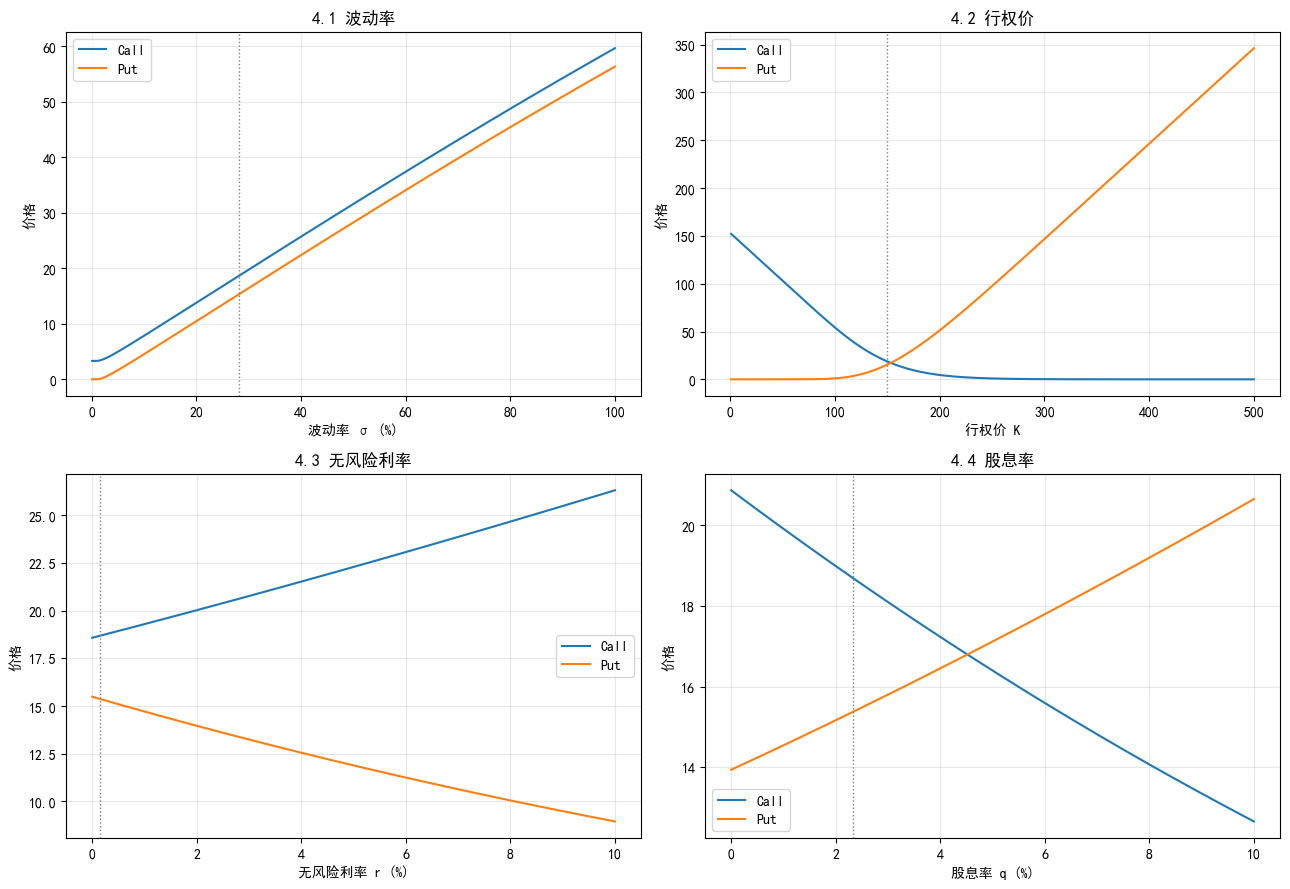

In [6]:
# 复现论文 4.1–4.4：其余参数固定为 Table 2，逐个改变 sigma、K、r、q
sweeps = [
    ("sigma", np.linspace(0.001, 1.0, 300), 100, "波动率 σ (%)", "4.1 波动率"),
    ("K", np.linspace(1.0, 500.0, 300), 1, "行权价 K", "4.2 行权价"),
    ("r", np.linspace(0.0, 0.10, 300), 100, "无风险利率 r (%)", "4.3 无风险利率"),
    ("q", np.linspace(0.0, 0.10, 300), 100, "股息率 q (%)", "4.4 股息率"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, x, scale, xlabel, title) in zip(axes.flat, sweeps):
    prm = BSMParams(**{**VANILLA, name: x})
    ax.plot(x * scale, bsm_call(prm), label="Call")
    ax.plot(x * scale, bsm_put(prm), label="Put")
    ax.axvline(VANILLA[name] * scale, color="gray", ls=":", lw=1)
    ax.set(xlabel=xlabel, ylabel="价格", title=title)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# 图中的特征值。Call 与 Put 的交点由平价关系决定，与 σ 无关
from scipy.optimize import brentq

S0, K0, r0, q0, T = VANILLA["S"], VANILLA["K"], VANILLA["r"], VANILLA["q"], VANILLA["T"]
gap = lambda **kw: bsm_call(BSMParams(**{**VANILLA, **kw})) - bsm_put(BSMParams(**{**VANILLA, **kw}))

features = pd.DataFrame({
    "平价关系给出的理论值": [
        S0 * np.exp((r0 - q0) * T),
        q0 + np.log(K0 / S0) / T,
        r0 + np.log(S0 / K0) / T,
        max(S0 * np.exp(-q0 * T) - K0 * np.exp(-r0 * T), 0),
        max(K0 * np.exp(-r0 * T) - S0 * np.exp(-q0 * T), 0),
    ],
    "数值求解": [
        brentq(lambda x: gap(K=x), 1, 500),
        brentq(lambda x: gap(r=x), -0.10, 0.10),
        brentq(lambda x: gap(q=x), 0.0, 0.10),
        bsm_call(BSMParams(**{**VANILLA, "sigma": 1e-6})),
        bsm_put(BSMParams(**{**VANILLA, "sigma": 1e-6})),
    ],
}, index=[
    "4.2 交点 K = S e^{(r-q)T}",
    "4.3 交点 r = q + ln(K/S)/T",
    "4.4 交点 q = r + ln(S/K)/T",
    "4.1 σ > 0 时 Call = max(Se^{-qT} - Ke^{-rT}, 0)",
    "4.1 σ > 0 时 Put = max(Ke^{-rT} - Se^{-qT}, 0)",
])
features

,平价关系给出的理论值,数值求解
4.2 交点 K = S e^{(r-q)T},153.3209,153.3209
4.3 交点 r = q + ln(K/S)/T,-0.0204,-0.0204
4.4 交点 q = r + ln(S/K)/T,0.0452,0.0452
"4.1 σ > 0 时 Call = max(Se^{-qT} - Ke^{-rT}, 0)",3.3159,3.3159
"4.1 σ > 0 时 Put = max(Ke^{-rT} - Se^{-qT}, 0)",0.0000,0.0000


In [8]:
# 论文 Table 3 的 10 条路径
table3 = pd.DataFrame({
    "S_T1": [118.33, 222.63, 186.53, 164.08, 159.09, 186.73, 106.61, 163.06, 129.26, 115.41],
    "选择": ["PUT", "CALL", "CALL", "CALL", "CALL", "CALL", "PUT", "CALL", "PUT", "PUT"],
    "S_T2": [116.77, 192.89, 192.94, 148.77, 116.78, 128.12, 90.52, 179.61, 144.82, 136.50],
    "payoff": [33.23, 42.89, 42.94, 0, 0, 0, 59.48, 29.61, 5.18, 13.5],
})

# 用表中的选择和 K = 150 重算 payoff
K = PAPER["K"]
table3["重算 payoff"] = np.where(table3["选择"] == "CALL",
                                np.maximum(table3["S_T2"] - K, 0),
                                np.maximum(K - table3["S_T2"], 0))
print("payoff 与重算值的最大差：", (table3["payoff"] - table3["重算 payoff"]).abs().max().round(4))
print("选择与 S_T1 > 150 一致：", ((table3["S_T1"] > K) == (table3["选择"] == "CALL")).all())
table3

payoff 与重算值的最大差： 0.0
选择与 S_T1 > 150 一致： True


,S_T1,选择,S_T2,payoff,重算 payoff
0,118.3300,PUT,116.7700,33.2300,33.2300
1,222.6300,CALL,192.8900,42.8900,42.8900
2,186.5300,CALL,192.9400,42.9400,42.9400
3,164.0800,CALL,148.7700,0.0000,0.0000
4,159.0900,CALL,116.7800,0.0000,0.0000
5,186.7300,CALL,128.1200,0.0000,0.0000
6,106.6100,PUT,90.5200,59.4800,59.4800
7,163.0600,CALL,179.6100,29.6100,29.6100
8,129.2600,PUT,144.8200,5.1800,5.1800
9,115.4100,PUT,136.5000,13.5000,13.5000


In [9]:
# 模型下的统计量，以及只有 10 条路径时的 95% 范围
def simulate(n, seed):
    rng = np.random.default_rng(seed)
    tau = PAPER["T2"] - PAPER["T1"]
    mu = PAPER["r"] - PAPER["q"] - 0.5 * PAPER["sigma"] ** 2
    s1 = PAPER["S"] * np.exp(mu * PAPER["T1"] + PAPER["sigma"] * np.sqrt(PAPER["T1"]) * rng.standard_normal(n))
    s2 = s1 * np.exp(mu * tau + PAPER["sigma"] * np.sqrt(tau) * rng.standard_normal(n))
    return s1, s2


def stats(s1, s2):
    call = s1 > K  # 与 Table 3 的选择方式一致
    pay = np.where(call, np.maximum(s2 - K, 0), np.maximum(K - s2, 0))
    return {
        "S_T1 均值": s1.mean(),
        "S_T1 > 150 的比例": call.mean(),
        "payoff 为 0 的比例": (pay == 0).mean(),
        "payoff 均值（未折现）": pay.mean(),
    }


s1, s2 = simulate(1_000_000, seed=1)
model = stats(s1, s2)

# 反复抽 10 条路径，看统计量的波动范围
rng = np.random.default_rng(2)
idx = rng.integers(0, len(s1), size=(20_000, 10))
small = pd.DataFrame([stats(s1[i], s2[i]) for i in idx])

paper_stats = stats(table3["S_T1"].to_numpy(), table3["S_T2"].to_numpy())

compare = pd.DataFrame({
    "论文 Table 3": paper_stats,
    "模型（100 万条路径）": model,
    "10 条路径 2.5% 分位": small.quantile(0.025),
    "10 条路径 97.5% 分位": small.quantile(0.975),
})
compare["是否在区间内"] = compare["论文 Table 3"].between(compare["10 条路径 2.5% 分位"],
                                                   compare["10 条路径 97.5% 分位"])
compare

,论文 Table 3,模型（100 万条路径）,10 条路径 2.5% 分位,10 条路径 97.5% 分位,是否在区间内
S_T1 均值,155.1730,154.9854,136.6301,175.2458,True
S_T1 > 150 的比例,0.6000,0.5262,0.2000,0.8000,True
payoff 为 0 的比例,0.3000,0.2534,0.0000,0.5000,True
payoff 均值（未折现）,22.6830,29.1289,12.3030,50.1558,True


### 结论

在 CRR (1979) Table 2 的 27 组参数下，本实现的欧式看涨期权价格与原文连续极限值的最大差为 0.005，处于原文两位小数的舍入范围内；10 万组随机参数下，看跌-看涨平价与股息等价关系的误差均处于浮点精度以内，价格上下界全部满足；Table 2 参数下的公式价格与风险中性密度数值积分结果一致。Chooser 定价方面，分解形式与 Rubinstein 闭式解一致，以看涨、看跌期权为基准的两种分解形式一致，$T_1 = T_2$ 时价格等于跨式组合价值，$T_1 \to 0$ 时趋于 $\max(C_0, P_0)$，价格随 $T_1$ 严格递增并位于二者之间。复现的四组敏感性曲线中，看涨期权价格随波动率和无风险利率上升、随行权价和股息率下降，看跌期权价格的变化方向与之相反（波动率除外，二者均随波动率上升），与论文 4.1–4.4 节的结论一致；两条曲线在行权价图中交于 $K = 153.32$，在股息率图中交于 $q = 4.52\%$，与平价关系给出的理论值一致，利率图的理论交点为 $r = -2.04\%$，位于图示范围之外。按论文 Table 3 所列的选择方式与 $K = 150$ 重算，10 条路径的 payoff 与表中数值完全一致；表中 $S_{T_1}$ 均值、$S_{T_1} > 150$ 的比例、payoff 为零的比例与未折现 payoff 均值分别为 155.17、0.60、0.30 与 22.68，对应的模型值为 154.99、0.53、0.25 与 29.13，四项统计量均落在 10 条路径下的 95% 抽样范围之内，与模型设定相符。